In [1]:
import sys
sys.path.append("/home/kongxiangyu/yongzhang/finnal_exp")
from utils.visualizations import plot_top_down_map , images_to_video_with_audio , combine_all_audio_data
from habitat.utils.visualizations.utils import images_to_video
from PIL import Image
import pickle , os
import numpy as np

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/home/kongxiangyu/anaconda3/envs/ss/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
path = '../dataset/pickle/v2/offline(version_final_2.0)/level3/17DRP5sb8fy/132.pkl'
with open(path , 'rb') as f:
    data = pickle.load(f)

In [26]:
print(data.keys())
print(data['obs'][0].keys())

dict_keys(['obs', 'reward', 'done', 'action_id', 'info', 'map', 'path_point', 'sound_id', 'greedy_action', 'total_sound_point'])
dict_keys(['rgb', 'depth', 'spectrogram', 'angle'])


In [27]:
print(f"reward : {len(data['reward'])} , done {len(data['done'])} , obs {len(data['obs'])} , action {len(data['action_id'])}")

reward : 24 , done 24 , obs 25 , action 24


In [40]:
data['done']

[False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 True]

In [28]:
data['total_sound_point']

[[[-0.308625, -0.008780999999999928, -0.269901],
  [-2.308625, 0.0020700000000000163, 0.730099],
  [-3.308625, 0.021233999999999975, -1.269901],
  [-5.308625, 0.021233999999999975, -2.269901]]]

In [41]:
data['action_id']

[2, 1, 1, 2, 1, 3, 1, 1, 3, 3, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 3, 1, 0]

In [30]:
data['reward']

[-0.01,
 0.99,
 0.99,
 -0.01,
 -1.01,
 -0.01,
 -1.01,
 -1.01,
 -0.01,
 -0.01,
 0.99,
 0.99,
 -0.01,
 0.99,
 0.99,
 -0.01,
 0.99,
 0.99,
 0.99,
 0.99,
 0.99,
 -0.01,
 0.99,
 9.99]

### draw depth

(-0.5, 127.5, 127.5, -0.5)

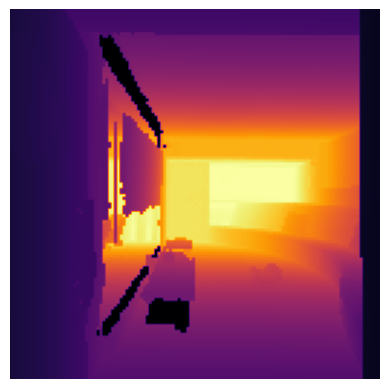

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# assume depth is your (128,128,1) array
depth_2d = np.squeeze(data['obs'][0]['depth'])  # becomes (128,128)

plt.imshow(depth_2d, cmap='inferno')
plt.axis('off')


### draw obs

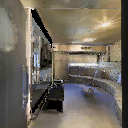

In [32]:
Image.fromarray(data['obs'][0]['rgb'])

### draw map

In [33]:
len(data['action_id'])

24

In [34]:
data['reward']

[-0.01,
 0.99,
 0.99,
 -0.01,
 -1.01,
 -0.01,
 -1.01,
 -1.01,
 -0.01,
 -0.01,
 0.99,
 0.99,
 -0.01,
 0.99,
 0.99,
 -0.01,
 0.99,
 0.99,
 0.99,
 0.99,
 0.99,
 -0.01,
 0.99,
 9.99]

In [35]:
data['action_id']

[2, 1, 1, 2, 1, 3, 1, 1, 3, 3, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 3, 1, 0]

In [36]:
data['info'][-1]

{'distance_to_goal': 0.0,
 'normalized_distance_to_goal': 0.0,
 'success': 1.0,
 'spl': 0.5999765691370905,
 'softspl': 0.5999765691370905,
 'na': 24,
 'sna': 0.5833333333333334,
 'top_down_map': {'map': array([[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]], dtype=uint8),
  'fog_of_war_mask': array([[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]], dtype=uint8),
  'agent_map_coord': (188, 379),
  'agent_angle': 3.141592653589793}}

In [37]:
import pickle
from PIL import Image
# path = '../dataset/pickle/v2/offline(version5)/qoiz87JEwZ2/3658.pkl'
# with open(path , 'rb') as f:
#     data = pickle.load(f)
Image.fromarray(data['map'][0]).save('./noise.png')

In [2]:
import os
path = '../dataset/pickle/v2/offline(version_final_1.5)/level3'
scenes = [os.path.join(path , i) for i in os.listdir(path)]
files = []
for s in scenes:
    files.extend([os.path.join(s , i) for i in os.listdir(s)])

In [7]:
import pickle
from PIL import Image
# path = '../dataset/pickle/v2/offline(version4)/level3/8WUmhLawc2A/1480.pkl'
# path = '../dataset/pickle/v2/greedy(hybirdnetwork_with_RGBD_train)/2n8kARJN3HM/44081.pkl'
os.makedirs("../test_img_2.0" , exist_ok=True)
for index , file in enumerate(files):
    print(file)
    with open(file , 'rb') as f:
        data = pickle.load(f)
        os.makedirs(f"../test_img_2.0/{file.split('/')[6]}" , exist_ok=True)
    Image.fromarray(data['map'][0]).save(f"../test_img_2.0/{file.split('/')[6]}/{file.split('/')[7][:-4]}.png")

../dataset/pickle/v2/offline(version_final_1.5)/level3/b8cTxDM8gDG/111.pkl
../dataset/pickle/v2/offline(version_final_1.5)/level3/b8cTxDM8gDG/498.pkl
../dataset/pickle/v2/offline(version_final_1.5)/level3/b8cTxDM8gDG/5976.pkl
../dataset/pickle/v2/offline(version_final_1.5)/level3/b8cTxDM8gDG/5280.pkl
../dataset/pickle/v2/offline(version_final_1.5)/level3/b8cTxDM8gDG/9819.pkl
../dataset/pickle/v2/offline(version_final_1.5)/level3/b8cTxDM8gDG/9046.pkl
../dataset/pickle/v2/offline(version_final_1.5)/level3/b8cTxDM8gDG/6849.pkl
../dataset/pickle/v2/offline(version_final_1.5)/level3/b8cTxDM8gDG/5126.pkl
../dataset/pickle/v2/offline(version_final_1.5)/level3/b8cTxDM8gDG/4.pkl
../dataset/pickle/v2/offline(version_final_1.5)/level3/b8cTxDM8gDG/4006.pkl
../dataset/pickle/v2/offline(version_final_1.5)/level3/b8cTxDM8gDG/3145.pkl
../dataset/pickle/v2/offline(version_final_1.5)/level3/b8cTxDM8gDG/7595.pkl
../dataset/pickle/v2/offline(version_final_1.5)/level3/b8cTxDM8gDG/3946.pkl
../dataset/pickle

In [57]:
path = '../dataset/pickle/v2/offline(version7)/level3/qoiz87JEwZ2/4418.pkl'
with open(path , 'rb') as f:
    data = pickle.load(f)


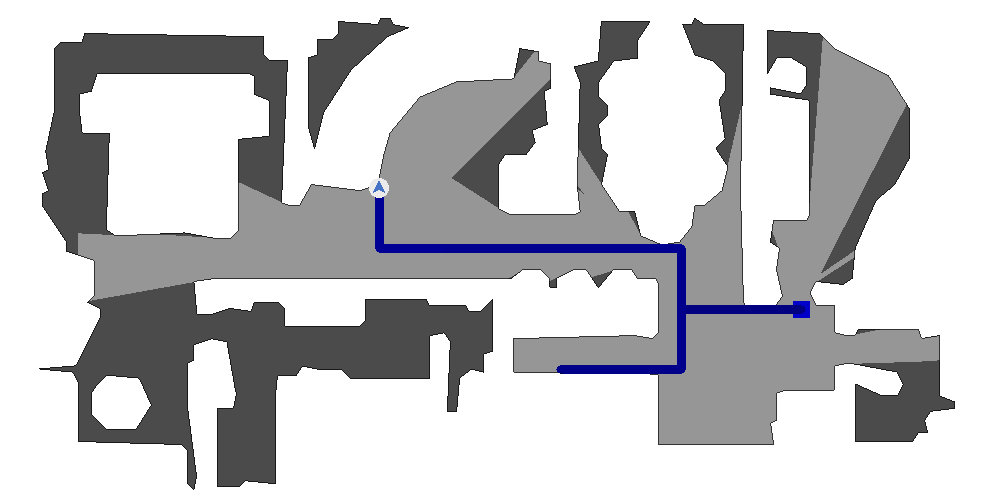

In [38]:
Image.fromarray(plot_top_down_map(data['info'][-1]))

### draw video

In [39]:
img = []
for i in data['info']:
    img.append(np.array(Image.fromarray(plot_top_down_map(i))))
images_to_video(images=img , output_dir='./' , video_name='version1_1' , fps=1)

2025-11-08 20:04:16,067 Video created: ./version1_1.mp4
100%|██████████| 24/24 [00:00<00:00, 553.32it/s]


In [43]:
img = []
for i in data['obs']:
    img.append(np.array(Image.fromarray(i['rgb'])))
images_to_video(images=img , output_dir='./' , video_name='version1_2' , fps=0.1)

2025-11-08 20:09:46,812 Video created: ./version1_2.mp4
100%|██████████| 25/25 [00:00<00:00, 926.13it/s]


### draw audio

In [22]:
combine_all_audio_data(data)

开始处理 14 个音频片段...
片段 0: 有声音 (最大值: 1.82e-01)
片段 1: 有声音 (最大值: 2.68e-01)
片段 2: 有声音 (最大值: 1.89e-01)
片段 3: 有声音 (最大值: 1.76e-01)
片段 4: 有声音 (最大值: 2.37e-01)
片段 5: 有声音 (最大值: 1.78e-01)
片段 6: 有声音 (最大值: 1.86e-01)
片段 7: 有声音 (最大值: 2.62e-01)
片段 8: 有声音 (最大值: 3.01e-01)
片段 9: 有声音 (最大值: 4.04e-01)
片段 10: 有声音 (最大值: 4.39e-01)
片段 11: 有声音 (最大值: 2.85e-01)
片段 12: 有声音 (最大值: 1.44e+00)
片段 13: 有声音 (最大值: 1.44e+00)
正在合并音频片段...
✅ 所有音频已合并保存至：combined_audio.wav
合并后音频形状：(224000, 2)
总时长：14.00 秒
